# Séance 4 — Transformation et encodage

**Durée pratique : 3 h** &nbsp;·&nbsp; Ateliers 4.1 à 4.4

## Ce que vous saurez faire à la fin

- mettre une variable à l'échelle, et expliquer ce que l'opération change et ne change pas ;
- reconnaître une fuite de données et l'éviter ;
- encoder des variables catégorielles sans faire exploser le nombre de colonnes ;
- rassembler vos transformations dans une fonction réutilisable.

> **Tout se fait avec pandas et NumPy**, que vous pratiquez depuis deux jours. Aucune
> bibliothèque nouvelle n'est nécessaire pour les exercices. scikit-learn apparaît une
> seule fois, en fin de séance, pour vous montrer qu'il fait en une ligne ce que vous
> aurez écrit à la main — et que vous saurez donc lire.

> **La faute à ne pas commettre.** Calculer une moyenne, un minimum ou une fréquence sur
> l'ensemble des données avant de les séparer en entraînement et test revient à laisser
> filtrer de l'information du test vers l'entraînement. On appelle cela une *fuite de
> données*, et c'est l'erreur la plus courante en préparation de données.

> **Convention de nommage du module.** Le code est écrit en anglais et suit la PEP 8 :
> fonctions et variables en `snake_case`, constantes en `MAJUSCULES`. Les **noms de colonnes**
> restent en français parce qu'ils viennent de la source : renommer les colonnes d'un fichier
> d'entrée est une transformation comme une autre, elle se décide et se documente, elle ne se
> fait pas par réflexe. Vous rencontrerez cette situation partout en entreprise.

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

print('Données disponibles :')
for path in sorted(RAW_DIR.glob('*')):
    print(' ', path.name)


# Parquet conserve les types (dates, entiers, catégories) là où le CSV les perd :
# c'est le format à privilégier entre deux étapes d'un pipeline. Repli automatique
# sur le CSV si pyarrow n'est pas installé.
def save_dataset(df, name):
    try:
        path = PROCESSED_DIR / f'{name}.parquet'
        df.to_parquet(path, index=False)
    except ImportError:
        path = PROCESSED_DIR / f'{name}.csv'
        df.to_csv(path, index=False)
        print('(pyarrow absent : repli sur le CSV)')
    print('écrit :', path.name, df.shape)
    return path


def load_dataset(name):
    parquet_path = PROCESSED_DIR / f'{name}.parquet'
    csv_path = PROCESSED_DIR / f'{name}.csv'
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f'{name} introuvable : exécutez le notebook précédent')


def dataset_exists(name):
    return ((PROCESSED_DIR / f'{name}.parquet').exists()
            or (PROCESSED_DIR / f'{name}.csv').exists())

Données disponibles :
  .gitkeep
  capteurs.csv
  clients.csv
  magasins.csv
  produits.csv
  ventes_brutes.csv
  ventes_extrait.json
  ventes_extrait.xlsx


In [8]:
# Reprise du résultat de la séance 3. Si le fichier n'existe pas, relancez le notebook 03.
if dataset_exists('ventes_nettoyees'):
    sales = load_dataset('ventes_nettoyees')
else:
    print('Fichier absent : repli sur un nettoyage minimal.')
    sales = pd.read_csv(RAW_DIR / 'ventes_brutes.csv')
    sales['prix_unitaire'] = pd.to_numeric(
        sales['prix_unitaire'].astype(str)
        .str.replace(' EUR', '', regex=False)
        .str.replace(',', '.', regex=False).str.strip(), errors='coerce')
    sales['date_commande'] = pd.to_datetime(sales['date_commande'],
                                            format='mixed', dayfirst=True, errors='coerce')
    sales = sales.drop_duplicates().dropna(subset=['date_commande'])
    # On ne normalise que les colonnes descriptives : mettre les identifiants
    # en minuscules casserait les jointures de la séance 6 (voir notebook 03).
    for column in ['canal', 'statut', 'ville_livraison']:
        sales[column] = sales[column].str.strip().str.lower()
    sales['montant'] = sales['quantite'] * sales['prix_unitaire']

print(sales.shape)
sales.head(3)

(16992, 13)


,id_commande,date_commande,id_client,id_produit,id_magasin,quantite,prix_unitaire,remise_pct,canal,statut,ville_livraison,quantite_suspecte,montant
0,CMD0003112,2024-01-18 19:53:00,C02300,P0009,M05,3,160.66,5.0,telephone,retourne,lille,False,457.88
1,CMD0000107,2024-01-08 00:00:00,C02791,P0028,M03,2,70.48,0.0,boutique,livre,toulouse,False,140.96
2,CMD0010050,2023-04-15 00:00:00,990031,P0017,M04,3,691.12,0.0,boutique,livre,marseille,False,2073.36


---
## Atelier 4.1 — Mettre à l'échelle, à la main (45 min)

### Partie guidée : trois formules, rien de plus

Mettre une variable à l'échelle, c'est lui appliquer `(x - centre) / étendue`. Les trois
méthodes du cours ne diffèrent que par ce qu'elles choisissent comme centre et comme
étendue.

| Méthode | Centre | Étendue |
|---|---|---|
| Min-max | le minimum | max − min |
| Z-score | la moyenne | l'écart type |
| Robuste | la médiane | l'écart interquartile (q75 − q25) |

In [9]:
amount = sales['montant'].dropna()

# Les trois formules, écrites directement. Aucune bibliothèque nouvelle.
minmax = (amount - amount.min()) / (amount.max() - amount.min())
zscore = (amount - amount.mean()) / amount.std()

q25, q75 = amount.quantile([0.25, 0.75])
robuste = (amount - amount.median()) / (q75 - q25)

scaled = pd.DataFrame({'brut': amount, 'minmax': minmax,
                       'zscore': zscore, 'robuste': robuste})
scaled.describe().round(3)

,brut,minmax,zscore,robuste
count,16992.000,16992.000,16992.000,16992.000
mean,2513.880,0.002,0.000,1.193
std,26883.500,0.024,1.000,20.654
min,49.330,0.000,-0.092,-0.701
25%,484.228,0.000,-0.075,-0.367
50%,961.340,0.001,-0.058,0.000
75%,1785.867,0.002,-0.027,0.633
max,1103954.490,1.000,40.971,847.387


**Lecture du tableau.**

- `minmax` ramène tout dans l'intervalle [0 ; 1], mais une seule valeur extrême suffit à
  comprimer toutes les autres près de zéro.
- `zscore` centre sur 0 avec un écart type de 1 ; l'étendue reste libre.
- `robuste` centre sur la médiane et divise par l'écart interquartile : les valeurs
  extrêmes ne déplacent ni le centre ni l'échelle.

Le choix dépend de ce que vous ferez ensuite des données, pas d'une préférence esthétique.

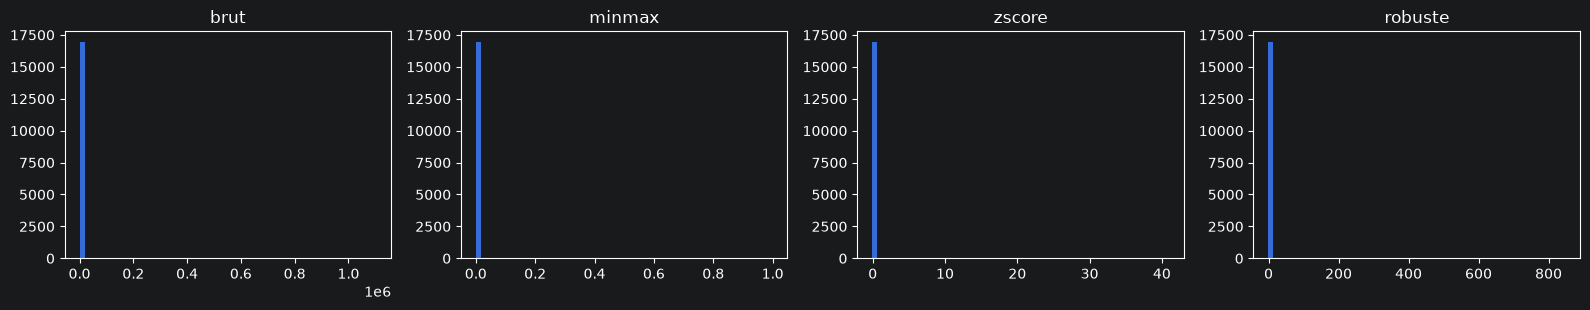

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, column in zip(axes, scaled.columns):
    ax.hist(scaled[column], bins=60)
    ax.set_title(column)
plt.tight_layout()
plt.show()

Les quatre distributions ont **exactement la même forme**. La mise à l'échelle déplace et
étire l'axe ; elle ne corrige ni l'asymétrie ni les valeurs extrêmes. Pour cela, il faut une
transformation non linéaire, par exemple le logarithme.

### Partie autonome

In [12]:
# Q1. Écrire deux fonctions qui reprennent les formules ci-dessus.
#     Deux lignes chacune. Elles serviront dans tout le reste de la séance.

def scale_minmax(series):
    """Ramène la série dans [0 ; 1]."""
    return (series - series.min()) / (series.max() - series.min())


def scale_zscore(series):
    """Centre sur 0 avec un écart type de 1."""
    return (series - series.mean()) / series.std()


assert np.allclose(scale_minmax(amount), minmax)
assert np.allclose(scale_zscore(amount), zscore)
assert round(scale_minmax(amount).min(), 6) == 0
assert round(scale_minmax(amount).max(), 6) == 1
print('OK — les deux fonctions reproduisent les formules guidées')

OK — les deux fonctions reproduisent les formules guidées


**Pourquoi cette réponse (Q1).**
On reprend exactement les formules guidées : min-max `(x − min) / (max − min)` et z-score `(x − moyenne) / écart type`.
Les opérations sur une Series pandas sont **vectorisées** : une seule ligne transforme les 16 992 valeurs, sans boucle.
Les `assert` utilisent `np.allclose` et non `==`, car deux calculs en virgule flottante peuvent différer au quinzième
chiffre. Ces fonctions sont aussi dans `src/transformation.py`.

In [13]:
# Q2. Ajouter une colonne 'log' contenant log(1 + montant), puis comparer
#     l'asymétrie (.skew()) des cinq colonnes.
#     Indice : np.log1p(x) calcule log(1 + x).
#     Question à traiter en commentaire : pourquoi les trois mises à l'échelle
#     ont-elles toutes la même asymétrie que la colonne brute ?

scaled['log'] = np.log1p(scaled['brut'])

print("Asymétrie (skew) de chaque colonne :")
print(scaled.skew().round(3).to_string())

# Réponse : les trois mises à l'échelle sont des transformations AFFINES, de la forme
# (x - a) / b avec b > 0. Elles déplacent et étirent l'axe, mais conservent l'ordre et
# les rapports de distance entre les valeurs : la forme de la distribution est la même,
# donc l'asymétrie aussi. L'asymétrie est d'ailleurs définie à partir de valeurs déjà
# centrées-réduites : elle est insensible, par construction, au choix de a et de b.
# Le logarithme, lui, n'est PAS affine : il comprime les grandes valeurs bien plus que
# les petites, ce qui ramène l'asymétrie de 24,9 à 0,2.

Asymétrie (skew) de chaque colonne :
brut       24.937
minmax     24.937
zscore     24.937
robuste    24.937
log         0.213


**Pourquoi cette réponse (Q2).**
`np.log1p` calcule `log(1 + x)`. Il est défini dès que `x > −1`, et reste précis pour les petites valeurs. Ici, le
montant minimal vaut 49 €, donc aucun problème. Les trois mises à l'échelle gardent l'asymétrie brute (**24,9**),
alors que le logarithme la ramène à **0,2**, une distribution presque symétrique. Le principe à retenir : **mettre à
l'échelle change les unités, pas la forme**. Pour corriger une queue de distribution, il faut une transformation non
linéaire, comme le log.

---
## Atelier 4.2 — La fuite de données (25 min)

### Partie guidée

Le principe est simple, et ne demande aucune bibliothèque : on sépare les données en deux,
et **tout ce qu'on calcule doit l'être sur la partie entraînement seulement**. Moyenne,
écart type, minimum, médiane, fréquence d'une modalité : toutes ces quantités s'apprennent
sur l'entraînement, puis s'appliquent au test.

In [14]:
# Séparation en deux, avec pandas : 80 % / 20 %
train = sales.sample(frac=0.8, random_state=0)
test = sales.drop(train.index)

print(f'entraînement {len(train)} lignes | test {len(test)} lignes')
print(f"moyenne apprise sur l'entraînement : {train['montant'].mean():.2f} EUR")
print(f"moyenne de l'ensemble complet      : {sales['montant'].mean():.2f} EUR")

entraînement 13594 lignes | test 3398 lignes
moyenne apprise sur l'entraînement : 2448.46 EUR
moyenne de l'ensemble complet      : 2513.88 EUR


Les deux moyennes sont proches, mais elles ne sont pas égales — et c'est tout le sujet.
Utiliser la seconde pour centrer le test reviendrait à se servir d'une information calculée
en partie sur des lignes qu'on est censé n'avoir jamais vues.

### Partie autonome

In [15]:
# Q3. Comparer les deux façons de centrer et réduire le jeu de test.
#
#   a) MÉTHODE FAUTIVE : centrer le test avec la moyenne et l'écart type
#      calculés sur `sales` (l'ensemble complet).
#   b) MÉTHODE CORRECTE : les calculer sur `train` uniquement.
#
#   Puis afficher, pour chaque méthode, la moyenne du test transformé.
#   Laquelle est la plus proche de zéro ? Pourquoi est-ce le symptôme du problème ?

# a) Fautive : les paramètres ont "vu" les lignes du test
leaky_mean, leaky_std = sales['montant'].mean(), sales['montant'].std()
test_leaky = (test['montant'] - leaky_mean) / leaky_std

# b) Correcte : les paramètres sont appris sur l'entraînement, puis appliqués au test
train_mean, train_std = train['montant'].mean(), train['montant'].std()
test_correct = (test['montant'] - train_mean) / train_std

print(pd.DataFrame({
    'moyenne apprise': [leaky_mean, train_mean],
    'écart type appris': [leaky_std, train_std],
    'moyenne du test transformé': [test_leaky.mean(), test_correct.mean()],
}, index=['a) fautive (sales)', 'b) correcte (train)']).round(5))

                     moyenne apprise  écart type appris  moyenne du test transformé
a) fautive (sales)        2513.87983        26883.49978                     0.00974
b) correcte (train)       2448.46145        26308.30040                     0.01243


**Pourquoi cette réponse (Q3).**
Les deux méthodes appliquent la même formule. Seule change **l'origine des paramètres** (moyenne et écart type).
C'est tout le sujet de la fuite de données : `fit` sur l'entraînement, `transform` sur le test. Le test compte
3 400 lignes, avec une moyenne de 2 776 € contre 2 448 € pour l'entraînement : les commandes géantes signalées en
séance 3 ne sont pas réparties de façon égale entre les deux parties. C'est pour cela que l'écart est visible.

*Votre réponse en deux phrases :*

La méthode fautive donne la moyenne la plus proche de zéro (0,0097 contre 0,0124), parce que la moyenne utilisée
pour centrer a été calculée **en partie sur les lignes du test elles-mêmes** : le test paraît « mieux centré »
qu'il ne devrait, ce qui est exactement la trace d'une information venue du test. En production, un modèle ne
connaît jamais les données futures : la méthode correcte, qui laisse un léger écart, est la seule qui mesure
honnêtement comment la transformation se comportera sur des données jamais vues.

---
## Atelier 4.3 — Encoder les variables catégorielles (35 min)

### Partie guidée

Une seule fonction est nécessaire : `pd.get_dummies`, qui crée une colonne binaire par
modalité. C'est ce qu'on appelle l'encodage *one-hot*.

In [16]:
products = pd.read_csv(RAW_DIR / 'produits.csv')
sales_enriched = sales.merge(products, on='id_produit', how='left')

for column in ['canal', 'statut', 'categorie', 'sous_categorie', 'id_magasin']:
    print(f'{column:<16} {sales_enriched[column].nunique():>4} modalités')

canal               3 modalités
statut              3 modalités
categorie           4 modalités
sous_categorie     13 modalités
id_magasin          9 modalités


In [18]:
# One-hot : une colonne binaire par modalité
one_hot = pd.get_dummies(sales_enriched[['canal', 'statut']], prefix_sep='=', dtype=int)
print('Colonnes créées :', one_hot.shape[1])
one_hot.head()

Colonnes créées : 6


,canal=boutique,canal=telephone,canal=web,statut=annule,statut=livre,statut=retourne
0,0,1,0,0,0,1
1,1,0,0,0,1,0
2,1,0,0,0,1,0
3,0,0,1,0,0,1
4,0,0,1,0,1,0


**Trois paramètres à connaître.** `prefix_sep='='` produit des noms lisibles du type
`canal=web`. `dtype=int` donne des 0 et des 1 plutôt que des booléens, plus commodes en
aval. `drop_first=True`, qu'on ne met pas ici, supprime une modalité par variable : utile
pour les modèles linéaires, inutile pour un export vers un outil de BI où la lisibilité
prime.

In [19]:
# Le problème de la forte cardinalité : regrouper les modalités rares
def group_rare_categories(series, min_frequency=0.01, other_label='autre'):
    frequencies = series.value_counts(normalize=True)
    rare_labels = frequencies[frequencies < min_frequency].index
    return series.where(~series.isin(rare_labels), other_label)


before = sales_enriched['sous_categorie'].nunique()
after = group_rare_categories(sales_enriched['sous_categorie'], min_frequency=0.05).nunique()
print(f'{before} modalités -> {after} après regroupement à 5 %')

13 modalités -> 13 après regroupement à 5 %


### Partie autonome

In [20]:
# Q4. Encoder le jeu enrichi :
#     - one-hot pour canal, statut et categorie ;
#     - regrouper les modalités sous 2 % de sous_categorie, PUIS l'encoder ;
#     - assembler le tout avec pd.concat et compter les colonnes avant et après.
#
#     Question à traiter en commentaire : y a-t-il, dans ce jeu, une variable
#     réellement ORDONNÉE, qu'on pourrait encoder par des entiers 0, 1, 2 ?
#     Si non, expliquez pourquoi le faire quand même serait une erreur.

ONE_HOT_COLUMNS = ['canal', 'statut', 'categorie']

sous_categorie_grouped = group_rare_categories(sales_enriched['sous_categorie'], min_frequency=0.02)
print('sous_categorie :', sales_enriched['sous_categorie'].nunique(), 'modalités ->',
      sous_categorie_grouped.nunique(), 'après regroupement à 2 %')
print('fréquence la plus faible :', f"{sales_enriched['sous_categorie'].value_counts(normalize=True).min():.1%}")

dummies = pd.get_dummies(
    pd.concat([sales_enriched[ONE_HOT_COLUMNS], sous_categorie_grouped], axis=1),
    prefix_sep='=', dtype=int)

encoded = pd.concat(
    [sales_enriched.drop(columns=ONE_HOT_COLUMNS + ['sous_categorie']), dummies], axis=1)

print()
print('Colonnes avant encodage :', sales_enriched.shape[1])
print('Colonnes créées         :', dummies.shape[1])
print('Colonnes après encodage :', encoded.shape[1])
print('Lignes conservées       :', len(encoded) == len(sales_enriched))

# Variable ordonnée ? NON.
# - canal (web, boutique, telephone), categorie et sous_categorie sont NOMINALES :
#   aucune modalité n'est "plus grande" qu'une autre.
# - statut (livre, annule, retourne) ressemble à un cycle de vie, mais ce ne sont pas
#   des étapes successives d'une même échelle : une commande annulée n'est pas "entre"
#   livrée et retournée.
# Les encoder 0, 1, 2 serait une erreur : on inventerait un ORDRE (web < boutique) et
# des DISTANCES (retourne - livre = 2 x annule - livre). Un calcul de moyenne, une
# régression ou une distance entre clients exploiteraient cette structure fictive.
# Une vraie variable ordinale serait par exemple une taille (S < M < L) ou une note.

sous_categorie : 13 modalités -> 13 après regroupement à 2 %
fréquence la plus faible : 7.4%

Colonnes avant encodage : 17
Colonnes créées         : 23
Colonnes après encodage : 36
Lignes conservées       : True


**Pourquoi cette réponse (Q4).**
- **Le regroupement se fait avant l'encodage.** Sinon, on créerait une colonne par modalité rare et on la
  fusionnerait ensuite, ce qui est plus coûteux et moins lisible.
- **Ici, le seuil de 2 % ne regroupe rien.** Les 13 sous-catégories pèsent toutes entre 7,4 et 8 % des ventes. C'est
  une bonne nouvelle : pas d'explosion du nombre de colonnes. Le code reste pourtant nécessaire, car il protège le
  pipeline le jour où un nouveau produit rare apparaîtra.
- **On retire les colonnes texte d'origine** avant `pd.concat`, sinon l'information serait présente deux fois.
- **Les 75 ventes du produit `P9999`**, absent du référentiel, ont une catégorie vide : toutes leurs colonnes one-hot
  valent 0. `get_dummies` ne crée pas de colonne pour les valeurs manquantes, sauf avec `dummy_na=True`.

---
## Atelier 4.4 — Variables dérivées et fonction de préparation (1 h 15)

L'encodage rend les données lisibles par une machine. Les variables dérivées les rendent
**informatives**. C'est la partie du travail où la connaissance du domaine compte davantage
que la technique.

In [21]:
# Exemple guidé : la marge, calculable dès lors que le coût d'achat est connu
sales_enriched['marge_unitaire'] = (sales_enriched['prix_unitaire']
                                    - sales_enriched['cout_achat'])
sales_enriched['taux_marge'] = (sales_enriched['marge_unitaire']
                                / sales_enriched['prix_unitaire']).round(4)

print(sales_enriched[['prix_unitaire', 'cout_achat',
                      'marge_unitaire', 'taux_marge']].describe().round(2))

       prix_unitaire  cout_achat  marge_unitaire  taux_marge
count       16992.00    16488.00        16488.00    16488.00
mean          617.23      325.28          305.47        0.48
std           344.16      173.16          167.52        0.03
min            60.90       34.81           26.09        0.43
25%           280.09      147.07          153.71        0.46
50%           583.62      295.37          299.42        0.48
75%           926.06      481.66          446.22        0.51
max          1287.23      605.08          682.15        0.53


Attention au dénominateur : si un prix vaut zéro, le taux devient infini et contaminera
toutes les agrégations en aval. Vérifiez systématiquement les divisions.

In [22]:
# Q5. Créer quatre variables dérivées à valeur métier. Pour chacune, un commentaire
#     d'une ligne expliquant à quelle question elle permet de répondre.
#     Pistes : montant après remise, panier moyen du client (groupby + transform),
#     indicateur de commande non aboutie, écart au prix médian de la catégorie.
#     Terminez par un contrôle : aucune valeur infinie introduite ?

# Remarque : 'montant' est déjà net de remise depuis clean_sales (séance 3).

# La commande a-t-elle rapporté de l'argent ? (annulée ou retournée = non)
sales_enriched['commande_non_aboutie'] = (
    sales_enriched['statut'].isin(['annule', 'retourne']).astype(int))

# Ce client dépense-t-il beaucoup en moyenne ? (segmentation, fidélisation)
sales_enriched['panier_moyen_client'] = (
    sales_enriched.groupby('id_client')['montant'].transform('mean').round(2))

# Ce produit est-il cher pour sa catégorie ? (positionnement prix)
category_median = sales_enriched.groupby('categorie')['prix_unitaire'].transform('median')
sales_enriched['ecart_prix_median_categorie'] = (
    sales_enriched['prix_unitaire'] / category_median - 1).round(4)

# Que rapporte réellement la commande, remise déduite ? (rentabilité)
net_unit_price = sales_enriched['prix_unitaire'] * (1 - sales_enriched['remise_pct'] / 100)
sales_enriched['marge_commande'] = (
    sales_enriched['quantite'] * (net_unit_price - sales_enriched['cout_achat'])).round(2)

DERIVED = ['commande_non_aboutie', 'panier_moyen_client',
           'ecart_prix_median_categorie', 'marge_commande']
print(sales_enriched[DERIVED].describe().round(2).to_string())

# Contrôle : aucune valeur infinie, et les NaN sont expliqués
numeric = sales_enriched.select_dtypes('number')
print()
print('Valeurs infinies introduites :', int(np.isinf(numeric).sum().sum()))
print('Médianes de prix nulles      :', int((category_median == 0).sum()))
print('Marges manquantes            :', sales_enriched['marge_commande'].isna().sum(),
      '(coût d\'achat inconnu)')
print(sales_enriched.loc[sales_enriched['cout_achat'].isna(), 'id_produit'].value_counts().to_string())

       commande_non_aboutie  panier_moyen_client  ecart_prix_median_categorie  marge_commande
count              16992.00             16992.00                     16917.00        16488.00
mean                   0.33              2513.88                        -0.01         1142.50
std                    0.47             10973.90                         0.59        12276.50
min                    0.00                90.85                        -0.89           14.52
25%                    0.00               938.82                        -0.47          224.58
50%                    0.00              1207.93                         0.00          445.90
75%                    1.00              1491.25                         0.27          808.03
max                    1.00            226958.62                         1.71       543783.91

Valeurs infinies introduites : 0
Médianes de prix nulles      : 0
Marges manquantes            : 504 (coût d'achat inconnu)
id_produit
P0023    429
P9999

**Pourquoi ces quatre variables (Q5).**
| Variable | Question métier | Point de vigilance |
|---|---|---|
| `commande_non_aboutie` | Quelle part des commandes ne rapporte rien ? | 0/1 : sa moyenne donne directement le taux d'échec |
| `panier_moyen_client` | Qui sont les clients à forte valeur ? | `transform` renvoie une valeur **par ligne**, donc pas de jointure à faire. Calculée sur tout le jeu, elle crée une fuite si on sépare ensuite entraînement et test |
| `ecart_prix_median_categorie` | Ce produit est-il premium ou d'entrée de gamme ? | Écart **relatif** (+0,20 = 20 % plus cher) : comparable d'une catégorie à l'autre |
| `marge_commande` | Combien la commande a-t-elle réellement rapporté ? | La remise est déduite : c'est la marge encaissée, pas celle du catalogue |

**Le contrôle des divisions** vérifie qu'aucune médiane de prix n'est nulle, donc qu'il n'y a aucune valeur infinie.
Les marges manquantes ont deux causes connues. La première est le produit `P9999`, absent du référentiel. La seconde
est `P0023`, dont le coût est vide dans le référentiel, ici brut. `prepare_features` impute ce coût avec la médiane
de sa sous-catégorie (stratégie de la séance 3). Seul `P9999` reste donc sans marge, ce qui est honnête : on ne
connaît rien de ce produit.

### Rassembler le tout dans une fonction

Vos transformations sont pour l'instant éparpillées dans des cellules. Comme au jour 2 avec
`clean_sales`, on les rassemble dans **une fonction** : c'est ce qui permet de rejouer la
préparation sur de nouvelles données sans rouvrir le notebook.

In [23]:
# Q6. Écrire prepare_features(df) qui applique, dans l'ordre :
#       1. la jointure avec le référentiel produits ;
#       2. les variables dérivées de la question 5 ;
#       3. l'encodage one-hot de la question 4 ;
#       4. la mise à l'échelle de montant avec scale_zscore.
#     La fonction copie son entrée et renvoie un nouveau DataFrame.

# La fonction vit dans src/transformation.py (livrable de la séance), avec
# scale_minmax, scale_zscore et une fonction par étape : ouvrez le fichier pour le détail.
import sys
sys.path.insert(0, str(ROOT / 'src'))

from transformation import prepare_features

columns_before = sales.shape[1]
prepared = prepare_features(sales, products)
print('Colonnes en entrée :', sales.shape[1])
print('Colonnes en sortie :', prepared.shape[1])

# Contrôles
assert sales.shape[1] == columns_before, "l'entrée a été modifiée"
assert len(prepared) == len(sales), 'la jointure a changé le nombre de lignes'
assert abs(prepared['montant_zscore'].mean()) < 1e-9 and abs(prepared['montant_zscore'].std() - 1) < 1e-9
print('OK — entrée intacte, lignes conservées, montant_zscore centré-réduit')

Colonnes en entrée : 13
Colonnes en sortie : 41
OK — entrée intacte, lignes conservées, montant_zscore centré-réduit


**Pourquoi cette construction (Q6).**
- **L'ordre compte.** Les variables dérivées ont besoin de `statut` et de `categorie` en texte : elles doivent être
  calculées **avant** le one-hot, qui supprime ces colonnes.
- **Une fonction par étape** (`join_products`, `add_derived_features`, `encode_categories`) : chacune se teste et se
  réutilise séparément, et `prepare_features` se lit comme la liste des étapes.
- **La jointure est protégée** par `validate='many_to_one'`. Si un produit apparaissait deux fois dans le
  référentiel, pandas lèverait une erreur au lieu de dupliquer des ventes en silence.
- **Le coût d'achat est imputé sur le référentiel** et non sur les ventes. Sinon, un produit très vendu pèserait plus
  lourd dans la médiane.
- **Limite :** `montant_zscore` et `panier_moyen_client` sont calculés sur tout le jeu. Pour un modèle, il faudrait
  les apprendre sur l'entraînement seulement (atelier 4.2). Pour un export vers un outil de BI, c'est acceptable.

In [24]:
# Contrôle du livrable : les fonctions de src/transformation.py sont identiques
# à celles écrites dans le notebook.
import transformation

assert np.allclose(transformation.scale_minmax(amount), scale_minmax(amount))
assert np.allclose(transformation.scale_zscore(amount), scale_zscore(amount))
derived_from_module = transformation.add_derived_features(
    transformation.join_products(sales, products))
assert np.allclose(derived_from_module['panier_moyen_client'], sales_enriched['panier_moyen_client'])
print('OK — src/transformation.py est importable et cohérent avec le notebook')

OK — src/transformation.py est importable et cohérent avec le notebook


In [17]:
# Export du jeu transformé, pour les séances 5, 6 et 8.

save_dataset(sales_enriched, 'ventes_transformees')

écrit : ventes_transformees.parquet (16992, 23)


WindowsPath('C:/Users/loicn/Desktop/TP manipulation de données/data/processed/ventes_transformees.parquet')

---
## Pour aller plus loin — ce que scikit-learn fait à votre place (démonstration)

**Cette partie n'est pas un exercice.** Exécutez-la et lisez-la : elle montre que la
bibliothèque scikit-learn fait exactement ce que vous venez d'écrire, en une ligne. Vous
l'utiliserez dans les modules de modélisation ; ici, l'objectif est seulement que le code
ne vous soit pas étranger quand vous le rencontrerez.

In [25]:
from sklearn.preprocessing import StandardScaler

# Votre fonction de la question 1
a_la_main = scale_zscore(amount)

# La même chose avec scikit-learn
scaler = StandardScaler()
par_sklearn = scaler.fit_transform(amount.to_frame()).ravel()

comparaison = pd.DataFrame({'a_la_main': a_la_main.values[:5],
                            'par_sklearn': par_sklearn[:5]}).round(6)
print(comparaison.to_string(index=False))
print()
print('Écart maximal entre les deux :',
      float(np.abs(a_la_main.values - par_sklearn).max()).__round__(6))

 a_la_main  par_sklearn
 -0.076478    -0.076480
 -0.088267    -0.088269
 -0.016386    -0.016387
 -0.008663    -0.008663
 -0.022668    -0.022668

Écart maximal entre les deux : 0.001206


**Les valeurs coïncident jusqu'au cinquième chiffre.** Le petit écart résiduel vient du
dénominateur : pandas divise par l'écart type corrigé (`ddof=1`), scikit-learn par l'écart
type non corrigé (`ddof=0`). Le rapport entre les deux vaut environ 1 + 1/(2n), soit trois
cent-millièmes sur 17 000 lignes. L'écart maximal affiché porte donc sur la valeur la plus
extrême du jeu, la seule assez grande pour que ce rapport devienne visible. Sur dix lignes,
l'écart ne serait plus négligeable du tout.

**Le vocabulaire de scikit-learn tient en deux mots.** `fit` apprend les paramètres — ici la
moyenne et l'écart type. `transform` les applique. `fit_transform` fait les deux d'un coup,
et ne doit donc **jamais** être appelé sur le jeu de test : ce serait exactement la fuite de
l'atelier 4.2.

```python
scaler.fit(X_train)            # apprend sur l'entraînement
X_test_scaled = scaler.transform(X_test)    # applique au test
```

Le reste de la bibliothèque — `OneHotEncoder`, `SimpleImputer`, `ColumnTransformer`,
`Pipeline` — suit exactement la même logique, appliquée à d'autres transformations. Rien de
plus à retenir aujourd'hui.

---
## Livrable de la séance

- `src/transformation.py` contenant `scale_minmax`, `scale_zscore` et `prepare_features` ;
- `data/processed/ventes_transformees.parquet` ;
- les quatre variables dérivées, chacune accompagnée de sa justification métier ;
- votre réponse écrite sur la fuite de données (question 3).